# E2 - Loading and visualizing data from flat files (using AI)

Student details:

Name and surname: Mahlatse Hendrik Motubatse 
Student number: MTBMAH005
Email address: MTBMAH@myuct.ac.za

##### Assignment Brief

Instructions
Note: This assignment will be done in class with the tutors using AI as a tool for coding. But it will count as an assignment, and it will be graded based on 

Structure of the directories and data files (including names)
Structure of the notebook, comments, and LLM prompts
How you have pushed your changes to the repository, including a new folder with the exercise and the necessary files.
This assignment is composed of 3 parts and makes use of the commands and methods you learned in the DataCamp assignments from Day 1 and Day 2.

Part 1 - Flat data and headers
The file for_nitpicker.dat found on the GitHub repository contains data from a CTD, the primary instrument used by oceanographers. Data obtained from a CTD are flat files with plenty of metadata. However, it used to be quite common for scientists to remove the headers and just work with the data, which is WRONG. 

The file does not contain any information about the variables. You can probably guess some of them, but that would lead to mistakes. You then wrote to the person who sent you the data, and received the following answer:

Hi Nitpicker,

I really have no time to dig out the original data with all the cumbersome metadata.

It is obvious that the first two columns are date and time, the third is depth and the 4th and 5th are T and salinity (in psu).

Please stop bothering me

Since you are a better scientist, you want to create a file that contains the right header, where the variable name also includes the units (in such a way that you can use the name for labelling the plots).

Using pandas and the DataFrame object, import the file in the python workspace and write a script to create a new file with the following features:

a proper name, helping you to know what the content is
a first row with the name of each column and the units (where appropriate)
Part 2 - profiles
Create a two-panels plot showing temperature and salinity profiles from the file you prepared in the previous assignment. The figure should be a 'small multiple sharing the y axis', as it is described in the DataCamp lesson from Day 2. The two panels should be one beside the other, with the proper labels and the two lines with different colours and no symbols.

You may find the following function useful:

def ddmm2dd(ddmm):     
"""     
Converts a position input from degrees and minutes to degrees and decimals     
Input is ddmm.cccc and output is dd.cccc     
Note, it does not check if positive or negative     
"""     
    thedeg = np.floor(ddmm/100.)     
    themin = (ddmm-thedeg*100.)/60.     
    return thedeg+themin
Part 3 - time series
Research cruises have an automatic scientific data system that records data from various meteorological and oceanographic instruments together with the position of the ship (the data log). These data are stored in a flat file. The file SAA2_WC_2017_metocean_10min_avg.csv found in the GitHub repository contains the data log from the SA Agulhas II winter cruise in the Southern Ocean in 2017.

Create a script to do the following operations

Load the CSV file in python, using the appropriate column for the time index. Check that the missing values are properly recognized.
The ship reached the southernmost location on July 4th. Use the time indexing to select the data from departure to that date included. All plots will be done using this selected set of data.
Plot the time series of temperature with the appropriate labels. Save the figure using the 'grayscale' style
Plot a histogram of the salinity distribution using bins of 0.5 psu between 30 and 35.
Calculate the mean, standard deviation and the interquartile range for temperature and salinity and present the results in a table.
Create a scatter plot of wind speed and air temperature, encoding the latitude information in colour. Wind speed is in meters per second and air temperature in degrees Celsius. Save this figure in PNG with a resolution of 300 DPI
Remember to upload all the scripts and data you used for the assignment in a new folder on your github repository. Paste the link in the text submission window to complete the submission. 

#### Answers:

##### Part 1:

In [2]:
import pandas as pd # Read the ASCII file — no existing header row df = pd.read_csv("data.txt", header=None, sep="\t") # change sep as needed # Assign column names at position 0 (the horizontal index) df.columns = ["col_A", "col_B", "col_C"] # match the number of columns # Write back — index=False keeps row numbers out of the file df.to_csv("data.txt", index=False, sep="\t")
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
from scipy import stats

In [3]:
# Define your column names
column_names = ["date", "time_(hh:mm)", "depth_(m)", "temperature_(°C)", "salinity (ppt)"]  # Replace with your actual column names

In [4]:
# Read the existing .dat file (tab-delimited, no header)
ctd_data = pd.read_csv('for_nitpicker.dat', sep="\t", header=None)

# Assign column names
ctd_data.columns = column_names

# Write back to the same file with headers, tab-delimited, no index
ctd_data.to_csv("your_file.dat", sep="\t", index = False)

##### Part 2:

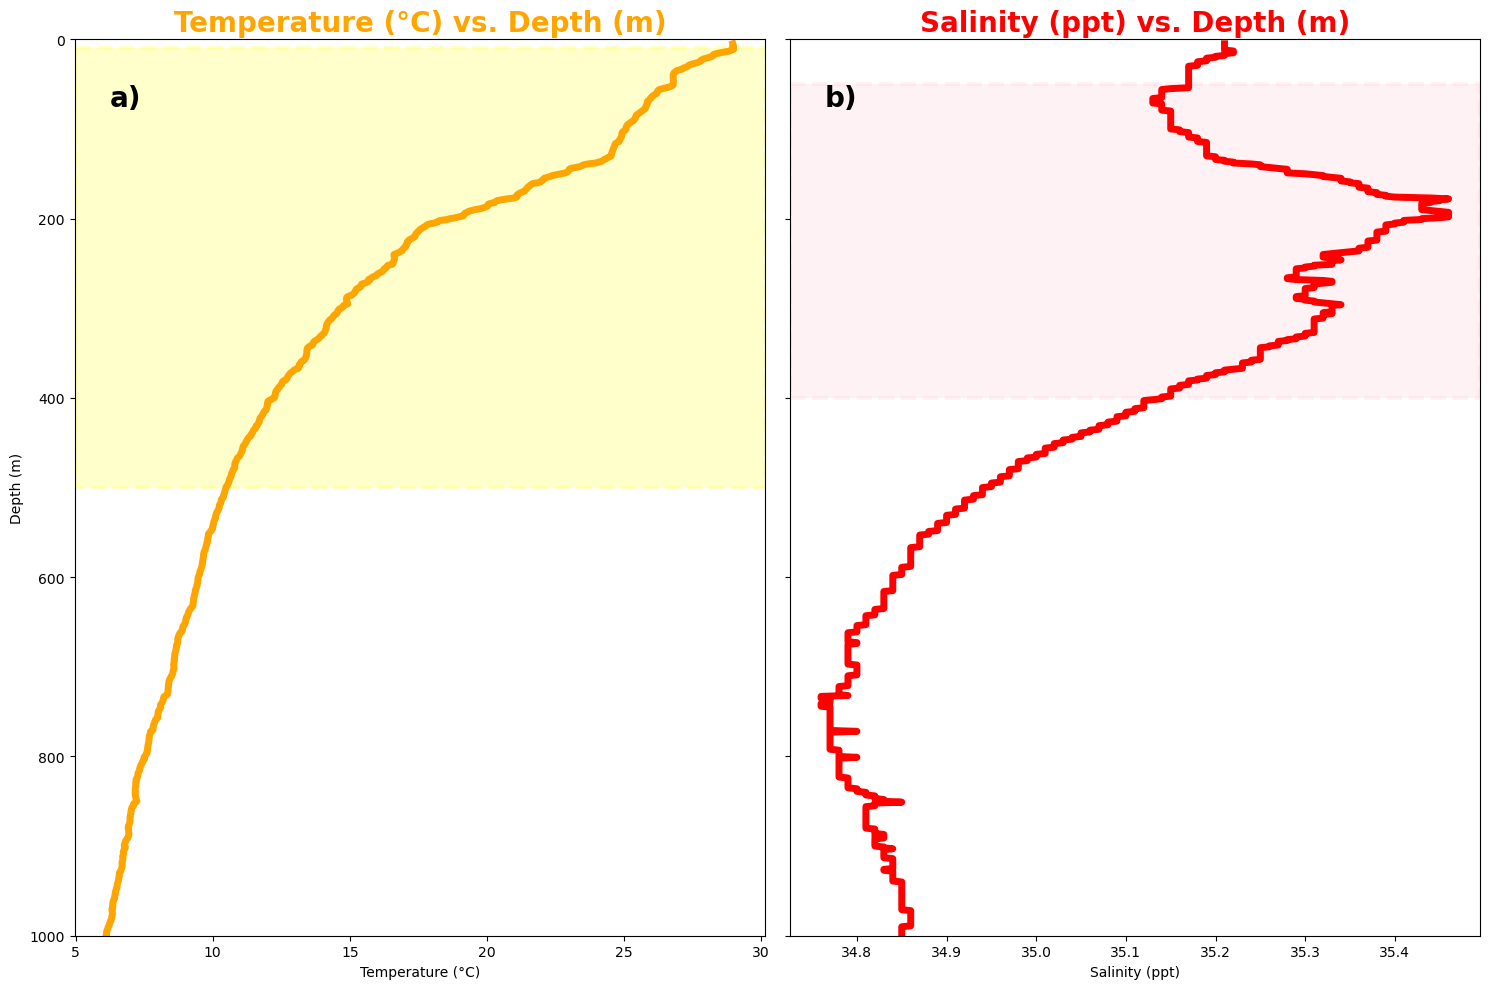

In [12]:
fig, ax = plt.subplots(ncols = 2, sharey = True, figsize = (15, 10))

ax[0].plot(ctd_data["temperature_(°C)"], ctd_data["depth_(m)"], color = "orange", linewidth = 5)
ax[0].set_xlabel("Temperature (°C)")
ax[0].set_ylabel("Depth (m)")
ax[0].set_title("Temperature (°C) vs. Depth (m)", size = 20, color = "orange", fontweight='bold')
ax[0].axhspan(10, 500, alpha=0.2, facecolor='yellow', linestyle = "--", edgecolor = "yellow", linewidth = 3, label = "Approx. Thermoclinic Region")
ax[0].set_ylim(0, 1000)
ax[0].text(0.05, 0.95, 'a)', transform=ax[0].transAxes, fontsize=20, fontweight='bold', va='top')
ax[0].invert_yaxis()

ax[1].plot(ctd_data["salinity (ppt)"], ctd_data["depth_(m)"], color = "red", linewidth = 5)
ax[1].set_xlabel("Salinity (ppt)")
ax[1].axhspan(50, 400, alpha=0.2, facecolor='pink', linestyle = "--", edgecolor = "pink", linewidth = 3, label = "Approx. Haloclinic Region")
ax[1].text(0.05, 0.95, 'b)', transform=ax[1].transAxes, fontsize=20, fontweight='bold', va='top')
ax[1].set_title("Salinity (ppt) vs. Depth (m)", size = 20, color = "red", fontweight='bold')

ax[1].sharey(ax[0])
plt.tight_layout(h_pad=1, w_pad=1)

Figure 1: Hydrographic parameters a) temperature (°C), and b) salinity (ppt) depth (m) profiles at an aribtary spatial location. The thermoclinic (yellow) and haloclinic (pink) depth ranges are shaded. 

##### PART 3:

In [14]:
# ── 1. Load the CSV from a local file ────────────────────────────────────────
# Place the CSV in the same directory as this script, or provide the full path.

# ── Step 1: Peek at column names ─────────────────────────────────────────────
temp = pd.read_csv("SAA2_WC_2017_metocean_10min_avg.csv", nrows=2)
print(temp.columns.tolist())

['id', 'TIME_SERVER', 'TIME_GPS', 'LATITUDE', 'N_S', 'LONGITUDE', 'E_W', 'HUMIDITY', 'BAROMETER', 'AIR_TEMPERATURE', 'WIND_SPEED_REL', 'WIND_SPEED_TRUE', 'WIND_DIR_REL', 'WIND_DIR_TRUE', 'PAR', 'TSG_SALINITY', 'TSG_TEMP']


In [ ]:
# ── 1. Load the CSV from a local file ────────────────────────────────────────
SAA2_dat = pd.read_csv(
    "SAA2_WC_2017_metocean_10min_avg.csv",
    parse_dates=["TIME_SERVER"],
    index_col="TIME_SERVER",
    na_values=[-9999, -999, 9999, "NaN", "nan", "NA", ""],
)

print("=== Raw data overview ===")
print(f"Shape            : {SAA2_dat.shape}")
print(f"Index dtype      : {SAA2_dat.index.dtype}")
print(f"Index start/end  : {SAA2_dat.index[0]}  →  {SAA2_dat.index[-1]}")
print(f"\nMissing values per column:\n{SAA2_dat.isna().sum()}\n")
print(SAA2_dat.head(3))

# ── 2. Subset: departure → 4 July 2017 (southernmost point) ──────────────────
subset = SAA2_dat.loc[: "2017-07-04"]
print(f"\nSubset shape : {subset.shape}")
print(f"Subset period: {subset.index[0]}  →  {subset.index[-1]}\n")

# ── Helper – resolve column names robustly ────────────────────────────────────
def find_col(df, candidates):
    """Return the first candidate that exists (case-insensitive)."""
    lower = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in lower:
            return lower[c.lower()]
    raise KeyError(f"None of {candidates} found. Columns: {list(df.columns)}")

# ── Column mapping to actual CSV headers ─────────────────────────────────────
col_temp = find_col(subset, ["AIR_TEMPERATURE"])
col_sal  = find_col(subset, ["TSG_SALINITY"])
col_wspd = find_col(subset, ["WIND_SPEED_TRUE", "WIND_SPEED_REL"])
col_lat  = find_col(subset, ["LATITUDE"])

print(f"Columns used → T:{col_temp}  S:{col_sal}  Wspd:{col_wspd}  Lat:{col_lat}")

# ── 3a. Time series of air temperature (grayscale style) ─────────────────────
with plt.style.context("grayscale"):
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(subset.index, subset[col_temp], linewidth=0.8)
    ax.set_xlabel("Date (UTC)", fontsize=11)
    ax.set_ylabel("Air Temperature (°C)", fontsize=11)
    ax.set_title("SA Agulhas II – Air Temperature (departure → 4 July 2017)", fontsize=12)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%d %b"))
    ax.xaxis.set_major_locator(plt.matplotlib.dates.DayLocator(interval=3))
    plt.xticks(rotation=30, ha="right")
    ax.grid(True, alpha=0.4)
    fig.tight_layout()
    fig.savefig("temperature_timeseries.png", dpi=150)
    print("Saved: temperature_timeseries.png")
plt.close()

# ── 3b. Histogram of salinity (bins of 0.5 psu, 30–35) ───────────────────────
sal_clean = subset[col_sal].dropna()
bin_edges = np.arange(30, 35.5, 0.5)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(sal_clean, bins=bin_edges, color="steelblue", edgecolor="white", linewidth=0.6)
ax.set_xlabel("Salinity (psu)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("SA Agulhas II – Salinity Distribution", fontsize=12)
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax.grid(True, axis="y", alpha=0.4)
fig.tight_layout()
fig.savefig("salinity_histogram.png", dpi=150)
print("Saved: salinity_histogram.png")
plt.close()

# ── 4. Summary statistics table ───────────────────────────────────────────────
def iqr(series):
    q75, q25 = np.nanpercentile(series.dropna(), [75, 25])
    return q75 - q25

stats_table = pd.DataFrame(
    {
        "Variable" : ["Air Temperature (°C)", "Salinity (psu)"],
        "Mean"     : [subset[col_temp].mean(), subset[col_sal].mean()],
        "Std Dev"  : [subset[col_temp].std(),  subset[col_sal].std()],
        "IQR"      : [iqr(subset[col_temp]),   iqr(subset[col_sal])],
    }
).set_index("Variable").round(3)

print("\n=== Summary Statistics ===")
print(stats_table.to_string())

# ── 5. Scatter plot: wind speed vs air temperature, coloured by latitude ──────
valid = subset[[col_wspd, col_temp, col_lat]].dropna()

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    valid[col_wspd],
    valid[col_temp],
    c=valid[col_lat],
    cmap="plasma",
    s=15,
    alpha=0.9,
    linewidths=0,
)
cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("Latitude (°S)", fontsize=10)
ax.set_xlabel("Wind Speed (m s$^{-1}$)", fontsize=11)
ax.set_ylabel("Air Temperature (°C)", fontsize=11)
ax.set_title(
    "SA Agulhas II – Wind Speed vs Air Temperature\n(coloured by latitude)",
    fontsize=12,
)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("windspeed_vs_airtemp.png", dpi=300)
print("Saved: windspeed_vs_airtemp.png  (300 DPI)")
plt.close()

print("\nAll done.")

#### AI Assistance: Code assisted by Claude (Anthropic, 2026) - https://claude.ai